In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import transformers
import torch 
import torchvision
from torch.utils.data import DataLoader 
from diffusers import DDPMScheduler, UNet2DModel
import matplotlib.pyplot as plt 
from torch import nn
from tqdm.auto import tqdm

#--------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Current Working device : ",device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Current Working device :  cuda


In [2]:
dataset = torchvision.datasets.MNIST(root='/data',train=True,download=True,transform=torchvision.transforms.ToTensor())
dataset

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 155kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.10MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.03MB/s]


Dataset MNIST
    Number of datapoints: 60000
    Root location: /data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [3]:
Train_Dataloader = DataLoader(
    dataset,
    shuffle=True,
    batch_size=8,
)

In [4]:
def corruption_function(x,amount):
    noise = torch.rand_like(x)
    amount = amount.view(-1, 1, 1, 1)
    return x*(1-amount) + noise*amount

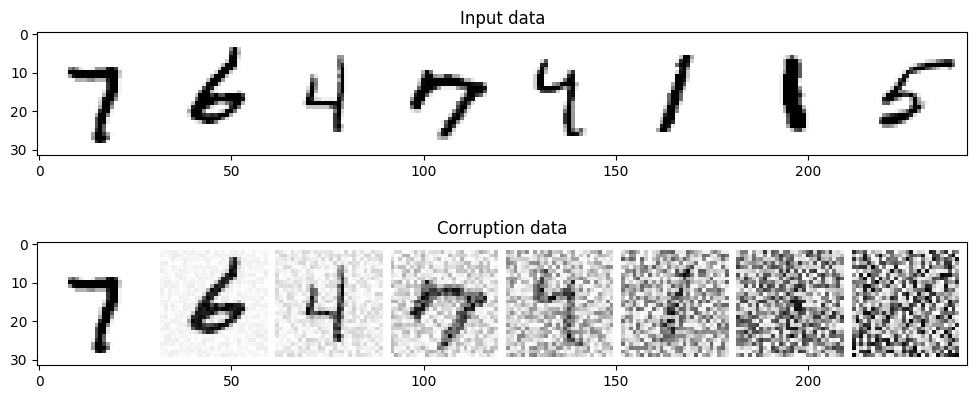

In [5]:
x,y = next(iter(Train_Dataloader))
fig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title('Input data')
axs[0].imshow(torchvision.utils.make_grid(x)[0], cmap='Greys')

amount = torch.linspace(0,1,8)

noised_x = corruption_function(x,amount)

axs[1].set_title("Corruption data")
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0],cmap="Greys")
plt.show()

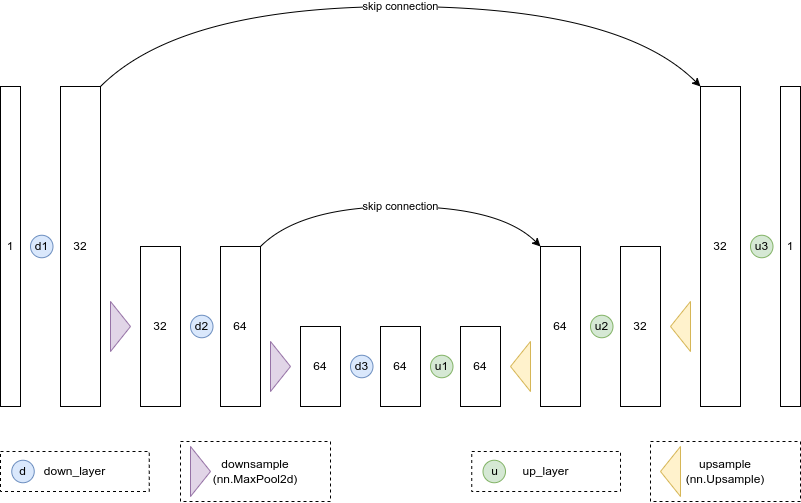
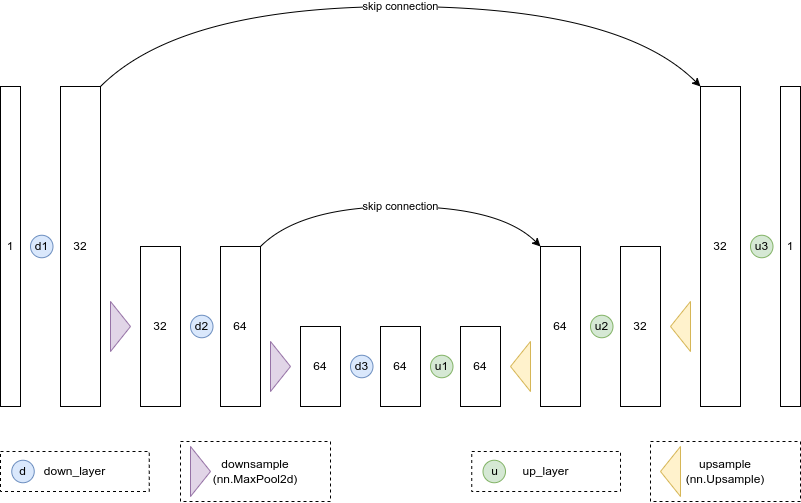

In [6]:
class UnetModel(nn.Module):
    def __init__(self,in_channels=1,out_channels=28):
        super().__init__()
        self.activation_fn = nn.SiLU()
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

        self.downLayers = nn.ModuleList(
            [
                nn.Conv2d(in_channels,32,kernel_size=5,padding=2),
                nn.Conv2d(32,64,kernel_size=5,padding=2),
                nn.Conv2d(64,64,kernel_size=5,padding=2),
            ]
        )

        self.upLayers = nn.ModuleList(
            [
                nn.Conv2d(64,64,kernel_size=5,padding=2),
                nn.Conv2d(64,32,kernel_size=5,padding=2),
                nn.Conv2d(32,out_channels,kernel_size=5,padding=2)
            ]
        )

    def forward(self,x):
        original_features = []
        for i,layer in enumerate(self.downLayers):
            # print(i)
            x = self.activation_fn(layer(x))
            if i<2:
                original_features.append(x)
                x = self.downscale(x)
        for i,layer in enumerate(self.upLayers):
            if i>0:
                x = self.upscale(x)
                x = x + original_features.pop()
                x = self.activation_fn(layer(x))
        return x 

In [7]:
BasicUnetModel = UnetModel(1,1)
x = torch.rand(8, 1, 28, 28)
BasicUnetModel(x).shape

torch.Size([8, 1, 28, 28])

In [11]:
Train_dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
)
Epochs = 5
BasicUNET = UnetModel(in_channels=1,out_channels=1)
BasicUNET = BasicUNET.to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(BasicUNET.parameters(),lr=0.0001)
losses = []

Training Started.


Training model:   0%|          | 0/5 [00:00<?, ?epoch/s]

Epoch : 1 | Avg Loss : 0.03624400051274915
Epoch : 2 | Avg Loss : 0.0258029963868831
Epoch : 3 | Avg Loss : 0.02446109929413938
Epoch : 4 | Avg Loss : 0.02338525348269482
Epoch : 5 | Avg Loss : 0.022393764145592892


(0.0, 0.1)

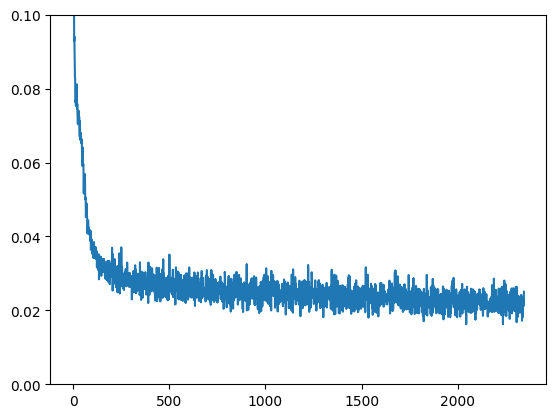

In [12]:
print("Training Started.")
pbar = tqdm(range(Epochs),unit="epoch",desc="Training model")
for epoch in pbar:
    BasicUNET.train()
    for x,y in Train_dataloader:
        optimizer.zero_grad()
        x = x.to(device)
        noise_amount = torch.rand(x.shape[0]).to(device)
        noisey_x = corruption_function(x,noise_amount)
        preds = BasicUNET(noisey_x)
        loss = loss_fn(preds,x)
        
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    avg_loss = sum(losses[-len(Train_dataloader):])/len(Train_dataloader)
    pbar.write(f"Epoch : {epoch+1} | Avg Loss : {avg_loss}")
    pbar.set_postfix({"Epoch": epoch+1,"Avg Loss": avg_loss})

plt.plot(losses)
plt.ylim(0,0.1)

In [14]:
def plot_results():
    x, y = next(iter(Train_dataloader))
    x = x[:8] 
    amount = torch.linspace(0, 1, x.shape[0]) 
    noised_x = corruption_function(x, amount)
    with torch.no_grad():
      preds = BasicUNET(noised_x.to(device)).detach().cpu()
    fig, axs = plt.subplots(3, 1, figsize=(12, 7))
    axs[0].set_title('Input data')
    axs[0].imshow(torchvision.utils.make_grid(x)[0].clip(0, 1), cmap='Greys')
    axs[1].set_title('Corrupted data')
    axs[1].imshow(torchvision.utils.make_grid(noised_x)[0].clip(0, 1), cmap='Greys')
    axs[2].set_title('Network Predictions')
    axs[2].imshow(torchvision.utils.make_grid(preds)[0].clip(0, 1), cmap='Greys');

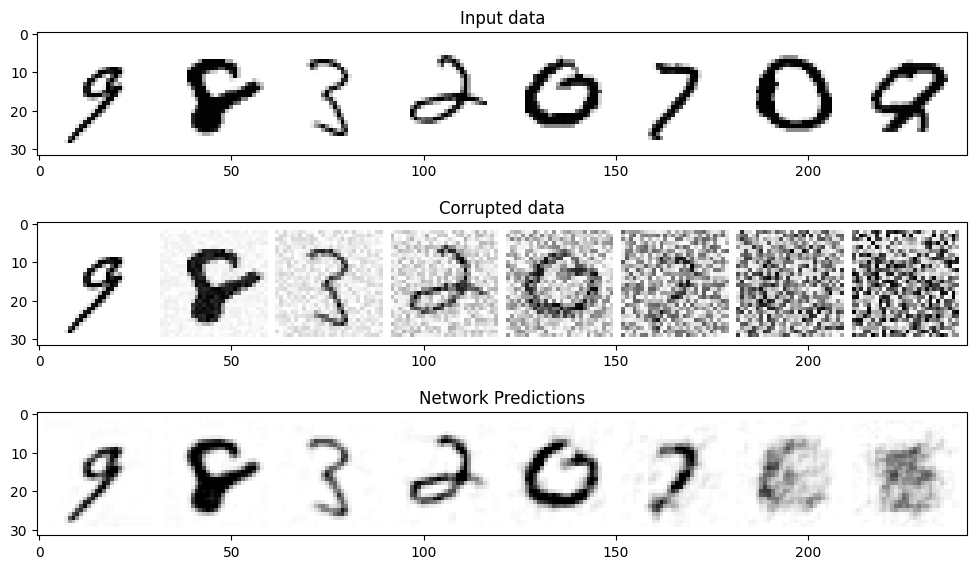

In [15]:
plot_results()

Sampling the outputs

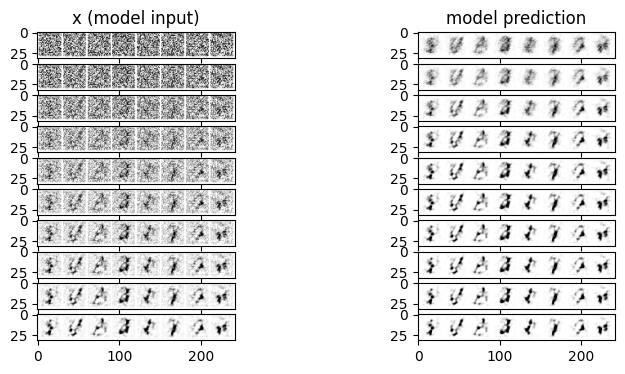

In [16]:
steps = 10
x = torch.rand([8,1,28,28]).to(device)
step_hist = [x.detach().cpu()]
prediction_hist = []

for i in range(steps):
    with torch.no_grad():
        pred = BasicUNET(x)
    prediction_hist.append(pred.detach().cpu())
    mix_factor = 1/(steps-i)
    x = x*(1-mix_factor) + pred*mix_factor
    step_hist.append(x.detach().cpu())

    
fig, axs = plt.subplots(steps, 2, figsize=(9, 4), sharex=True)
axs[0,0].set_title('x (model input)')
axs[0,1].set_title('model prediction')
for i in range(steps):
    axs[i, 0].imshow(torchvision.utils.make_grid(step_hist[i])[0].clip(0, 1), cmap='Greys')
    axs[i, 1].imshow(torchvision.utils.make_grid(prediction_hist[i])[0].clip(0, 1), cmap='Greys')        
        

# DDPM Diffusion Model

In [17]:
UNET_model = UNet2DModel(
    sample_size=28, 
    in_channels=1, 
    out_channels=1,  
    layers_per_block=2,  
    block_out_channels=(32, 64, 64),  
    down_block_types=( 
        "DownBlock2D", 
        "AttnDownBlock2D", 
        "AttnDownBlock2D",
    ), 
    up_block_types=(
        "AttnUpBlock2D", 
        "AttnUpBlock2D", 
        "UpBlock2D",   
      ),
) 
UNET_model.to(device)

UNet2DModel(
  (conv_in): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=32, out_features=128, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 32, eps=1e-05, affine=True)
          (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=128, out_features=32, bias=True)
          (norm2): GroupNorm(32, 32, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(32, 32, ker

In [18]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(UNET_model.parameters(),lr=0.0001)
Epochs = 5

In [20]:
pbar = tqdm(range(Epochs),unit="epoch",desc="Training model")
for epoch in pbar:
    loss_per_epoch = 0.0
    UNET_model.train()
    for x,y in Train_dataloader:
        x = x.to(device)
        noise_amount = torch.rand(x.shape[0]).to(device)
        noisy_x = corruption_function(x,noise_amount)
        preds = UNET_model(noisy_x,0).sample

        loss = loss_fn(preds,x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_per_epoch = loss_per_epoch + loss.item()
    pbar.write(f"Epoch : {epoch+1} | Avg loss : {loss_per_epoch/len(Train_dataloader)}")
    pbar.set_postfix({"Epoch": epoch+1,"Avg Loss": avg_loss})

Training model:   0%|          | 0/5 [00:00<?, ?epoch/s]

Epoch : 1 | Avg loss : 0.014714127199958637
Epoch : 2 | Avg loss : 0.013359390459319295
Epoch : 3 | Avg loss : 0.012698594838190181
Epoch : 4 | Avg loss : 0.012097720626686046
Epoch : 5 | Avg loss : 0.011843641136667684


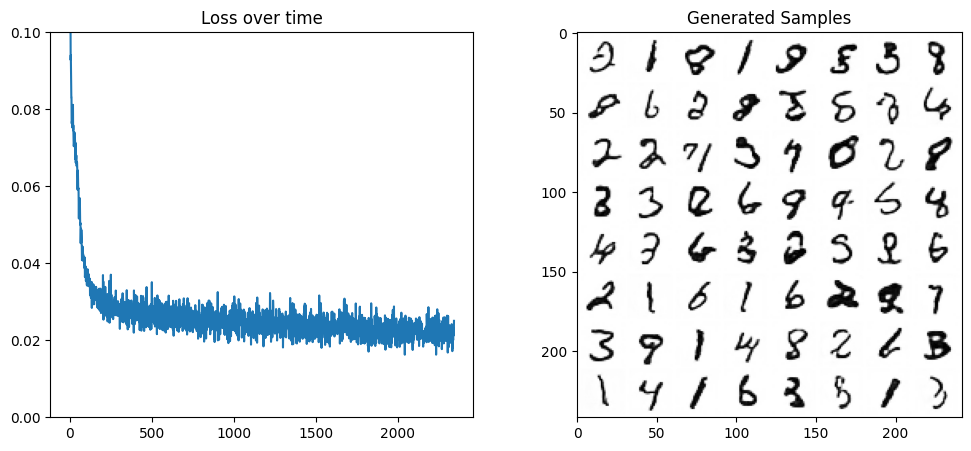

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Losses
axs[0].plot(losses)
axs[0].set_ylim(0, 0.1)
axs[0].set_title('Loss over time')

# Samples
n_steps = 40
x = torch.rand(64, 1, 28, 28).to(device)
for i in range(n_steps):
  noise_amount = torch.ones((x.shape[0], )).to(device) * (1-(i/n_steps)) 
  with torch.no_grad():
    pred = UNET_model(x, 0).sample
  mix_factor = 1/(n_steps - i)
  x = x*(1-mix_factor) + pred*mix_factor

axs[1].imshow(torchvision.utils.make_grid(x.detach().cpu(), nrow=8)[0].clip(0, 1), cmap='Greys')
axs[1].set_title('Generated Samples');